# Streaming Incremental Predictive Coding — Sweep Analysis

## Background

**Incremental Predictive Coding (iPC)** (Salvatori et al., ICLR 2024) updates value nodes and weights simultaneously at every inference timestep, removing the need for separate E-step/M-step scheduling. However, in standard mini-batch training, a forward-pass initialization is still required each time the batch changes, costing O(L) sequential operations.

**Core hypothesis:** In a streaming setting where inputs change gradually (temporally correlated observations), the value nodes from the previous timestep serve as a warm start for the current input. This eliminates the need for forward-pass reinitialization and enables true single-step (T=1) operation per new observation.

## Methods

Five algorithm variants are compared:

- **Streaming iPC**: Value nodes persist across observations with no reinitialization. The most aggressive variant — relies entirely on temporal correlation for warm-starting.
- **Forward Init iPC**: Standard approach — runs a full top-down forward pass to reinitialize value nodes before each observation. Serves as the upper-bound baseline for iPC.
- **EMA iPC**: Blends persistent value nodes with forward-pass predictions via exponential moving average: `x = beta * x_old + (1 - beta) * x_forward`. A compromise between streaming and forward_init.
- **BP (Streaming)**: Standard backpropagation with SGD on the same temporally correlated data stream. Controls for whether any algorithm can handle the streaming regime.
- **BP (Shuffled)**: Standard backpropagation with i.i.d. shuffled data. The "ideal conditions" upper bound for standard training.

## Task

**Rotating MNIST**: A single MNIST digit is continuously rotated by delta degrees per step. After a full 360-degree rotation, a new random digit is drawn. The network receives flattened 28x28 images and predicts one-hot class labels. Online accuracy is measured *before* each weight update.

In [12]:
# Data collection command:
# `python -m phd.research_utils.scripts.mlflow_download --tracking-uri=$MLFLOW_TRACKING_URI --experiment=streaming-ipc-sweeps --output-dir=data/`

# import subprocess, os
# subprocess.run([
#     'python', '-m', 'phd.research_utils.scripts.mlflow_download',
#     f'--tracking-uri={os.environ["MLFLOW_TRACKING_URI"]}',
#     '--experiment=streaming-ipc-sweeps',
#     '--output-dir=data/',
# ], check=True)

INFO:__main__:Tracking URI: sqlite:////home/edan/mlflow/mlruns.db
INFO:__main__:Found experiment 'streaming-ipc-sweeps' (id=4)
INFO:__main__:Found 108 runs
INFO:__main__:Discovered 7 metric names from 10 sample runs
INFO:__main__:Metrics to download: ['accuracy', 'accuracy_std', 'asymptotic_accuracy', 'asymptotic_energy', 'average_energy', 'energy', 'num_params']
Downloading: 100%|██████████| 108/108 [00:09<00:00, 10.85it/s]
INFO:__main__:Saved 108 param rows to data/streaming_ipc_sweeps_params.csv
INFO:__main__:Saved 9696 metric rows to data/streaming_ipc_sweeps_metrics.csv
INFO:__main__:108/108 runs saved successfully


CompletedProcess(args=['python', '-m', 'phd.research_utils.scripts.mlflow_download', '--tracking-uri=sqlite:////home/edan/mlflow/mlruns.db', '--experiment=streaming-ipc-sweeps', '--output-dir=data/'], returncode=0)

In [13]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

def repeat_baseline_acc(delta_degrees=5):
    """Accuracy of a trivial 'predict previous label' baseline.
    
    During a rotation (360/delta steps), the label is constant.
    The baseline is wrong only on the first step after a digit switch.
    """
    steps_per_rotation = 360 / delta_degrees
    return (steps_per_rotation - 1) / steps_per_rotation

def add_repeat_baseline(delta_degrees=5, ax=None):
    """Add a horizontal line for the repeat-previous-label baseline."""
    ax = ax or plt.gca()
    acc = repeat_baseline_acc(delta_degrees)
    ax.axhline(acc, color='grey', linestyle='--', linewidth=1, alpha=0.7)

print(f"Repeat baseline accuracies: delta=1° → {repeat_baseline_acc(1):.4f}, "
      f"delta=5° → {repeat_baseline_acc(5):.4f}, delta=15° → {repeat_baseline_acc(15):.4f}")

Repeat baseline accuracies: delta=1° → 0.9972, delta=5° → 0.9861, delta=15° → 0.9583


In [14]:
save_path = 'figures/'
config_data_path = 'data/streaming_ipc_sweeps_params.csv'
run_data_path = 'data/streaming_ipc_sweeps_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)

# Show sweep names and run counts
{k: len(v) for k, v in config_dfs.items()}

{'streaming_width_sweep': 6,
 'streaming_depth_sweep': 9,
 'streaming_delta_sweep': 9,
 'forward_init_delta_sweep': 9,
 'ema_beta_sweep': 12,
 'streaming_gamma_sweep': 9,
 'streaming_T_sweep': 12,
 'streaming_ipc_lr': 5,
 'forward_init_ipc_lr': 5,
 'ema_ipc_lr': 5,
 'bp_streaming_lr': 5,
 'bp_shuffled_lr': 5}

## Figure 1: Variant Comparison (Best LR per variant)

The central question: does streaming iPC (no reinitialization) match forward_init iPC (full reinit each step)? And how do both compare to standard backprop?

Each variant is shown at its best learning rate (selected by final 5% accuracy). All use the default architecture (3-layer, 256 hidden, ReLU) with 5-degree rotation and T=1 inference step.

**What to look for:**
- If streaming iPC matches forward_init, temporal correlation alone provides sufficient warm-starting.
- If BP (shuffled) >> BP (streaming), the streaming data order itself is harmful for standard training.
- The gap between streaming iPC and BP baselines shows whether PC's persistent state offers an advantage in the streaming regime.

In [15]:
# Get best LR for each variant from Phase 1 sweeps
variant_sweeps = [
    'streaming_ipc_lr', 'forward_init_ipc_lr', 'ema_ipc_lr',
    'bp_streaming_lr', 'bp_shuffled_lr',
]
variant_config_dfs = {k: config_dfs[k] for k in variant_sweeps if k in config_dfs}
variant_run_dfs = {k: run_dfs[k] for k in variant_sweeps if k in run_dfs}

best_config_dfs, best_run_dfs, best_hyperparam_vals = get_best_ablation_values(
    variant_config_dfs, variant_run_dfs,
    metric_col='accuracy',
    metric_direction='max',
    metric_type='final_avg',
)

print("Best hyperparameters per variant:")
for k, v in best_hyperparam_vals.items():
    print(f"  {k}: {v}")


=== streaming_ipc_lr ===

Configuration: (no split vars) | # runs: 1
  Best full_command=python train.py mlflow=True log_individual_seeds=True algorithm=ipc ipc.variant=streaming ipc.T=1 ipc.gamma=0.5 model.num_layers=3 model.hidden_dim=256 model.activation=relu data.delta_degrees=5 train.total_steps=100000 train.log_freq=1000 ipc.alpha=${eval:2**-12} seed=[1, 2, 3]


=== forward_init_ipc_lr ===

Configuration: (no split vars) | # runs: 1
  Best full_command=python train.py mlflow=True log_individual_seeds=True algorithm=ipc ipc.variant=forward_init ipc.T=1 ipc.gamma=0.5 model.num_layers=3 model.hidden_dim=256 model.activation=relu data.delta_degrees=5 train.total_steps=100000 train.log_freq=1000 ipc.alpha=${eval:2**-6} seed=[1, 2, 3]


=== ema_ipc_lr ===

Configuration: (no split vars) | # runs: 1
  Best full_command=python train.py mlflow=True log_individual_seeds=True algorithm=ipc ipc.variant=ema ipc.ema_beta=0.9 ipc.T=1 ipc.gamma=0.5 model.num_layers=3 model.hidden_dim=256 model.

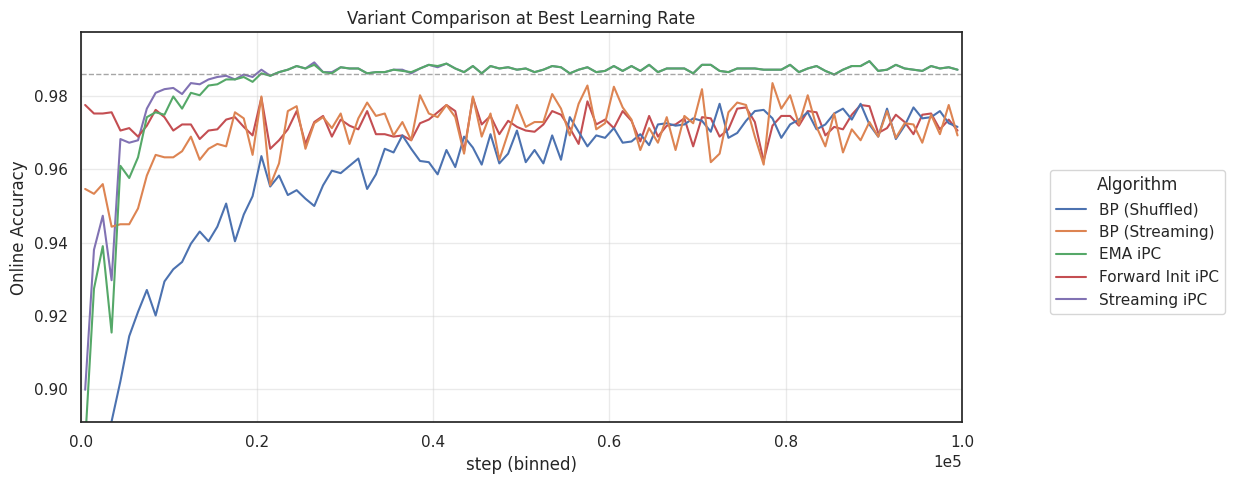

In [16]:
# Learning curves: best config per variant
combined_run_df = pd.concat(list(best_run_dfs.values()))
combined_config_df = pd.concat(
    [df.assign(variant=k) for k, df in best_config_dfs.items()]
)

algo_map = {
    'streaming_ipc_lr': 'Streaming iPC',
    'forward_init_ipc_lr': 'Forward Init iPC',
    'ema_ipc_lr': 'EMA iPC',
    'bp_streaming_lr': 'BP (Streaming)',
    'bp_shuffled_lr': 'BP (Shuffled)',
}
combined_config_df['Algorithm'] = combined_config_df['variant'].map(algo_map)
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()

plot_learning_curves(
    run_df=combined_run_df,
    config_df=combined_config_df,
    n_bins=200,
    figsize=(10, 5),
    y_col='accuracy',
    y_label='Online Accuracy',
    hue_col='Algorithm',
    legend_title='Algorithm',
    show_ci=True,
)
add_repeat_baseline(delta_degrees=5)
plt.title('Variant Comparison at Best Learning Rate')
plt.tight_layout()
plt.show()

## Figure 2: LR Sensitivity per Variant

Weight learning rate (alpha for iPC, optimizer LR for BP) is the most critical hyperparameter. This sweep tests alpha in {1e-4, 5e-4, 1e-3, 5e-3} across all variants with gamma=0.5, T=1.

**What to look for:**
- Whether streaming and forward_init iPC prefer similar alpha values (suggesting the update dynamics are similar despite different initialization).
- Whether the optimal LR differs between PC and BP (PC's Hebbian updates have different gradient scaling).
- Flat vs steep sensitivity curves — robust variants are preferable for practical use.

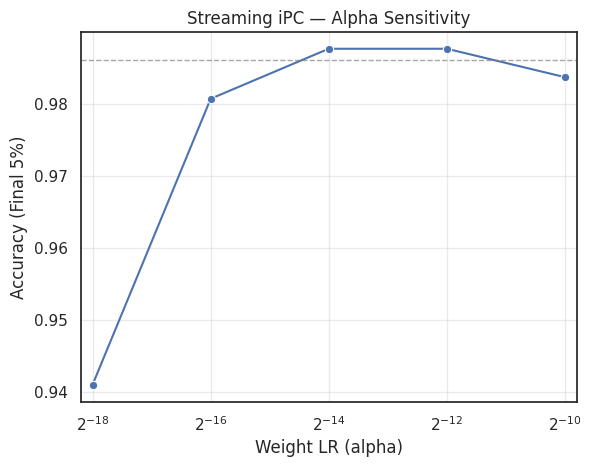

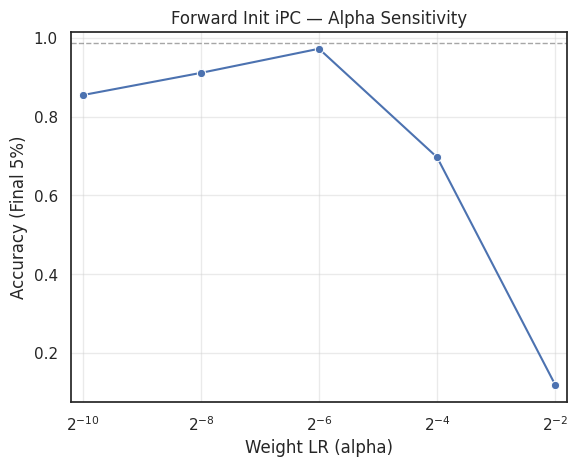

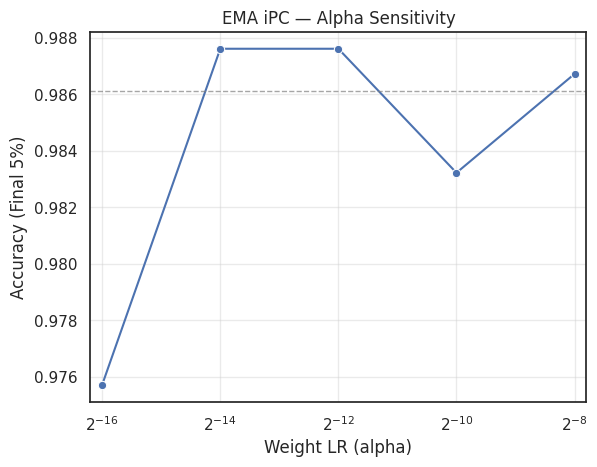

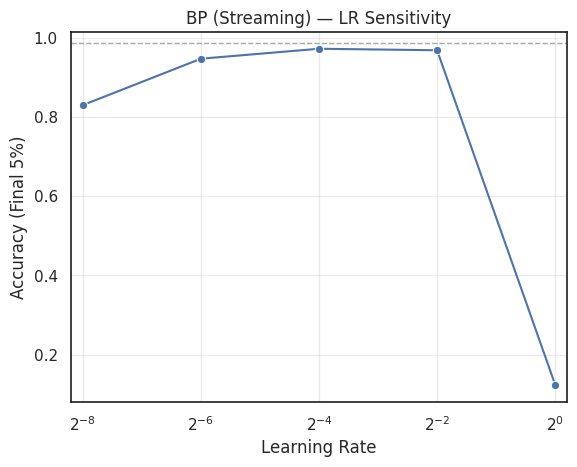

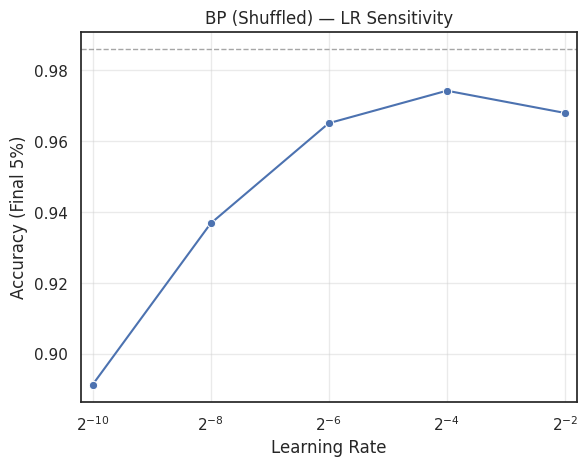

In [17]:
# LR sensitivity for iPC variants
for sweep_name in ['streaming_ipc_lr', 'forward_init_ipc_lr', 'ema_ipc_lr']:
    if sweep_name not in config_dfs:
        continue
    plot_param_sensitivity(
        run_df=run_dfs[sweep_name],
        config_df=config_dfs[sweep_name],
        x_col='ipc.alpha',
        title=f'{algo_map.get(sweep_name, sweep_name)} — Alpha Sensitivity',
        x_label='Weight LR (alpha)',
        y_label='Accuracy',
        metric_col='accuracy',
        metric_type='final_avg',
        pow_2_x_axis=True,
    )
    add_repeat_baseline(delta_degrees=5)
    plt.show()

# LR sensitivity for BP variants
for sweep_name in ['bp_streaming_lr', 'bp_shuffled_lr']:
    if sweep_name not in config_dfs:
        continue
    plot_param_sensitivity(
        run_df=run_dfs[sweep_name],
        config_df=config_dfs[sweep_name],
        x_col='optimizer.learning_rate',
        title=f'{algo_map.get(sweep_name, sweep_name)} — LR Sensitivity',
        x_label='Learning Rate',
        y_label='Accuracy',
        metric_col='accuracy',
        metric_type='final_avg',
        pow_2_x_axis=True,
    )
    add_repeat_baseline(delta_degrees=5)
    plt.show()

## Figure 3: Inference Steps (T) Comparison

Standard iPC typically uses T=20+ inference steps per observation. The streaming hypothesis is that temporal correlation reduces the required T, ideally to T=1. This sweep tests T in {1, 2, 4, 8} for streaming iPC, each at its own best alpha.

**Important note on "step" semantics:** The x-axis ("step") counts **observations seen**, not weight updates. Each observation triggers T inner iPC updates. So at step 100k:
- **T=1**: 100k observations, 100k weight updates
- **T=8**: 100k observations, 800k weight updates

This means T=8 does 8x more compute per observation. Figure 3b re-plots against total weight updates to give a compute-normalized comparison.

**What to look for:**
- If T=1 matches T=8 per observation (Fig 3a), the warm-start from temporal correlation fully compensates for fewer inference steps.
- If T=1 matches T=8 per update (Fig 3b), then T=1 is also compute-efficient — extra inference steps don't help even given the same compute budget.
- If T=8 wins per observation but T=1 wins per update, then T=1 is more efficient but T>1 can trade compute for accuracy.


=== streaming_T_sweep ===

Configuration: ipc.T=2**0 | # runs: 1
  Best ipc.alpha=2**-14

Configuration: ipc.T=2**1 | # runs: 1
  Best ipc.alpha=2**-14

Configuration: ipc.T=2**2 | # runs: 1
  Best ipc.alpha=2**-14

Configuration: ipc.T=2**3 | # runs: 1
  Best ipc.alpha=2**-14



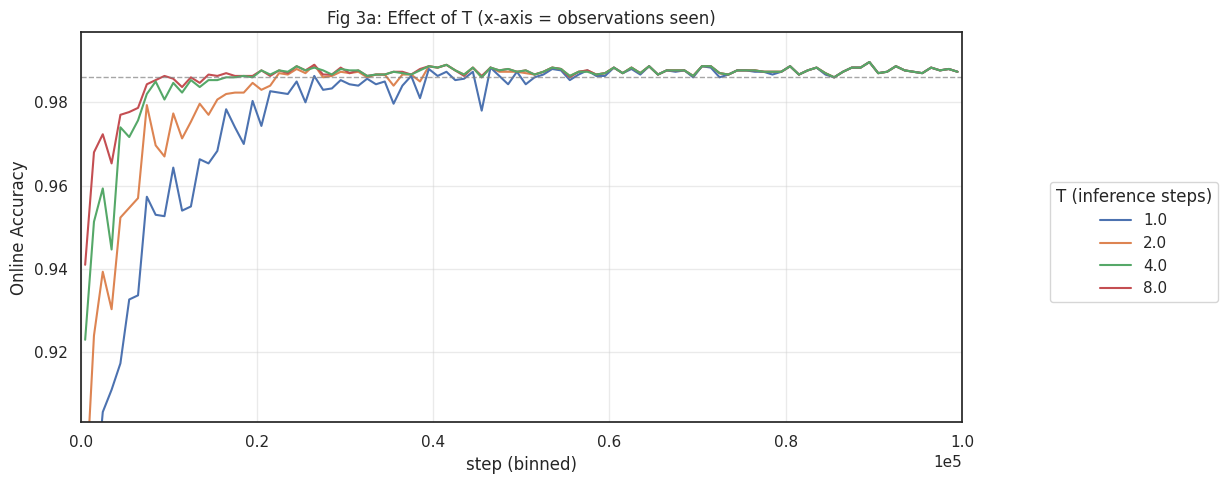

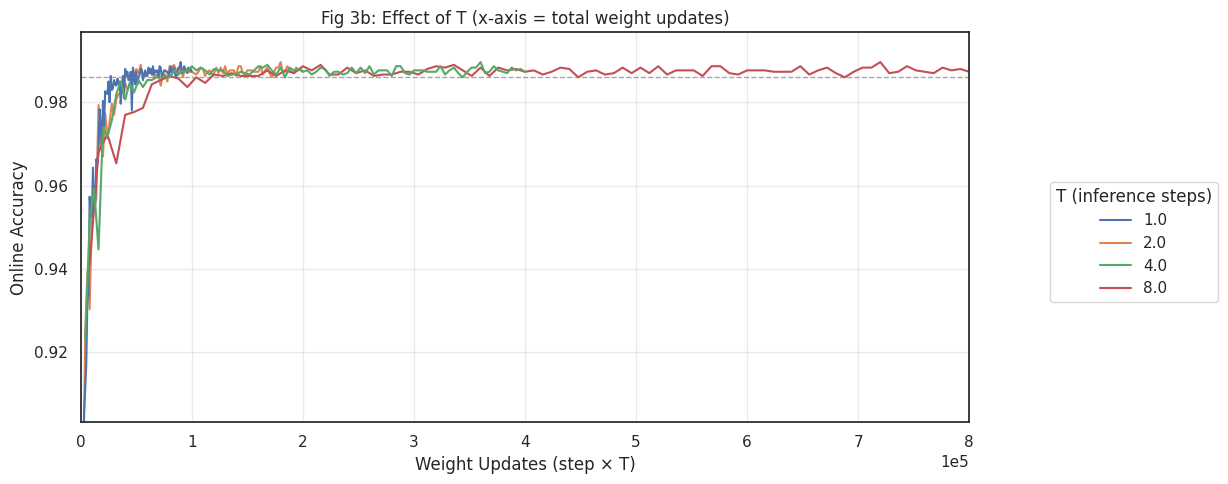

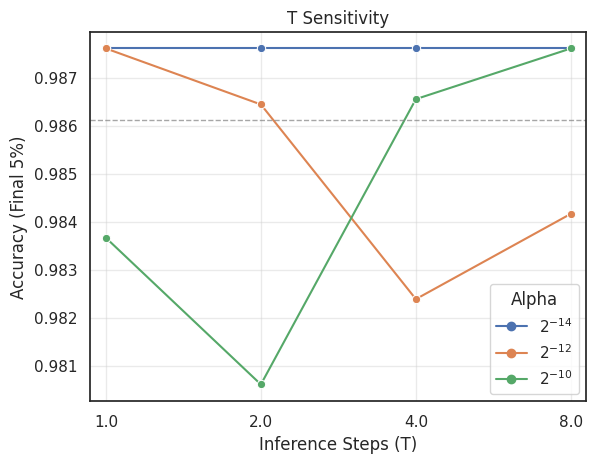

In [18]:
if 'streaming_T_sweep' in config_dfs:
    T_config = config_dfs['streaming_T_sweep']
    T_runs = run_dfs['streaming_T_sweep']

    # Best alpha per T value
    best_T_config, best_T_runs, best_T_vals = get_best_ablation_values(
        {'streaming_T_sweep': T_config},
        {'streaming_T_sweep': T_runs},
        sweep_ablation_vars={'streaming_T_sweep': ['ipc.alpha']},
        sweep_split_vars={'streaming_T_sweep': ['ipc.T']},
        split_dfs_by_split_vars=True,
        metric_col='accuracy',
        metric_direction='max',
        metric_type='final_avg',
    )

    combined_T_run = pd.concat(list(best_T_runs.values()))
    combined_T_config = pd.concat(
        [df.assign(split=k) for k, df in best_T_config.items()]
    )
    combined_T_config['T'] = combined_T_config['ipc.T'].astype(str)
    valid_ids = combined_T_config['run_id'].unique()
    combined_T_run = combined_T_run[combined_T_run['run_id'].isin(valid_ids)]

    # Fig 3a: Learning curves by observation step
    plot_learning_curves(
        run_df=combined_T_run,
        config_df=combined_T_config,
        n_bins=200,
        figsize=(10, 5),
        y_col='accuracy',
        y_label='Online Accuracy',
        hue_col='T',
        legend_title='T (inference steps)',
        show_ci=True,
    )
    add_repeat_baseline(delta_degrees=5)
    plt.title('Fig 3a: Effect of T (x-axis = observations seen)')
    plt.tight_layout()
    plt.show()

    # Fig 3b: Learning curves by total weight updates (step * T)
    combined_T_run_updates = combined_T_run.merge(
        combined_T_config[['run_id', 'ipc.T']].drop_duplicates(), on='run_id',
    )
    combined_T_run_updates['update_step'] = combined_T_run_updates['step'] * combined_T_run_updates['ipc.T']

    plot_learning_curves(
        run_df=combined_T_run_updates,
        config_df=combined_T_config,
        n_bins=200,
        figsize=(10, 5),
        x_col='update_step',
        y_col='accuracy',
        y_label='Online Accuracy',
        hue_col='T',
        legend_title='T (inference steps)',
        show_ci=True,
    )
    add_repeat_baseline(delta_degrees=5)
    plt.title('Fig 3b: Effect of T (x-axis = total weight updates)')
    plt.xlabel('Weight Updates (step × T)')
    plt.tight_layout()
    plt.show()

    # T sensitivity plot
    plot_param_sensitivity(
        run_df=T_runs,
        config_df=T_config,
        x_col='ipc.T',
        title='T Sensitivity',
        x_label='Inference Steps (T)',
        y_label='Accuracy',
        metric_col='accuracy',
        metric_type='final_avg',
        hue_col='ipc.alpha',
        legend_title='Alpha',
        pow_2_legend=True,
    )
    add_repeat_baseline(delta_degrees=5)
    plt.show()

## Figure 4: EMA Beta Comparison

The EMA variant blends old value nodes with a fresh forward-pass prediction: `x = beta * x_old + (1 - beta) * x_forward`. This interpolates between two extremes:
- **beta = 0**: Full forward-init reinit (equivalent to forward_init variant)
- **beta = 1**: Pure persistence (equivalent to streaming variant)

Intermediate values (beta = 0.5, 0.9) test whether partial reinit helps — keeping some memory of the previous state while nudging value nodes toward the new input's prediction.

**What to look for:**
- Whether an intermediate beta outperforms both extremes, suggesting the optimal strategy is a blend.
- Whether beta = 0.9 (strong persistence) or beta = 0.5 (balanced) is preferred — indicates how much the forward pass adds.

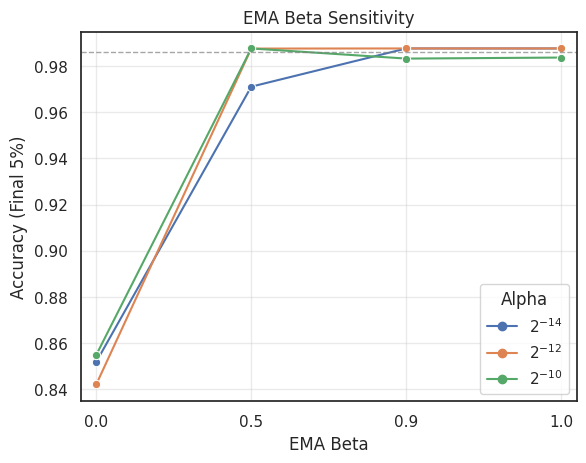

In [19]:
if 'ema_beta_sweep' in config_dfs:
    beta_config = config_dfs['ema_beta_sweep']
    beta_runs = run_dfs['ema_beta_sweep']

    plot_param_sensitivity(
        run_df=beta_runs,
        config_df=beta_config,
        x_col='ipc.ema_beta',
        title='EMA Beta Sensitivity',
        x_label='EMA Beta',
        y_label='Accuracy',
        metric_col='accuracy',
        metric_type='final_avg',
        hue_col='ipc.alpha',
        legend_title='Alpha',
        pow_2_legend=True,
    )
    add_repeat_baseline(delta_degrees=5)
    plt.show()

## Figure 5: Rotation Speed Comparison

The rotation speed (delta_degrees) controls the strength of temporal correlation between consecutive observations:
- **delta = 1 deg/step**: Very slow rotation, high temporal correlation. 360 steps per digit.
- **delta = 5 deg/step**: Moderate rotation. 72 steps per digit. (Default setting.)
- **delta = 15 deg/step**: Fast rotation, low temporal correlation. 24 steps per digit.

Streaming iPC's advantage should scale with temporal correlation: with slow rotation, value nodes barely need to change between steps, so persistence is nearly optimal. With fast rotation, the warm-start degrades and forward_init should recover its advantage.

**What to look for:**
- At delta=1, streaming iPC should closely match or exceed forward_init (minimal value node drift).
- At delta=15, the gap between streaming and forward_init should widen (stale value nodes hurt more).
- The crossover point where forward_init becomes preferable indicates the regime boundary for streaming iPC.


=== streaming_delta_sweep ===

Configuration: data.delta_degrees=2**0 | # runs: 1
  Best ipc.alpha=2**-12

Configuration: data.delta_degrees=5.0 | # runs: 1
  Best ipc.alpha=2**-14

Configuration: data.delta_degrees=15.0 | # runs: 1
  Best ipc.alpha=2**-12


=== forward_init_delta_sweep ===

Configuration: data.delta_degrees=2**0 | # runs: 1
  Best ipc.alpha=2**-6

Configuration: data.delta_degrees=5.0 | # runs: 1
  Best ipc.alpha=2**-6

Configuration: data.delta_degrees=15.0 | # runs: 1
  Best ipc.alpha=2**-6



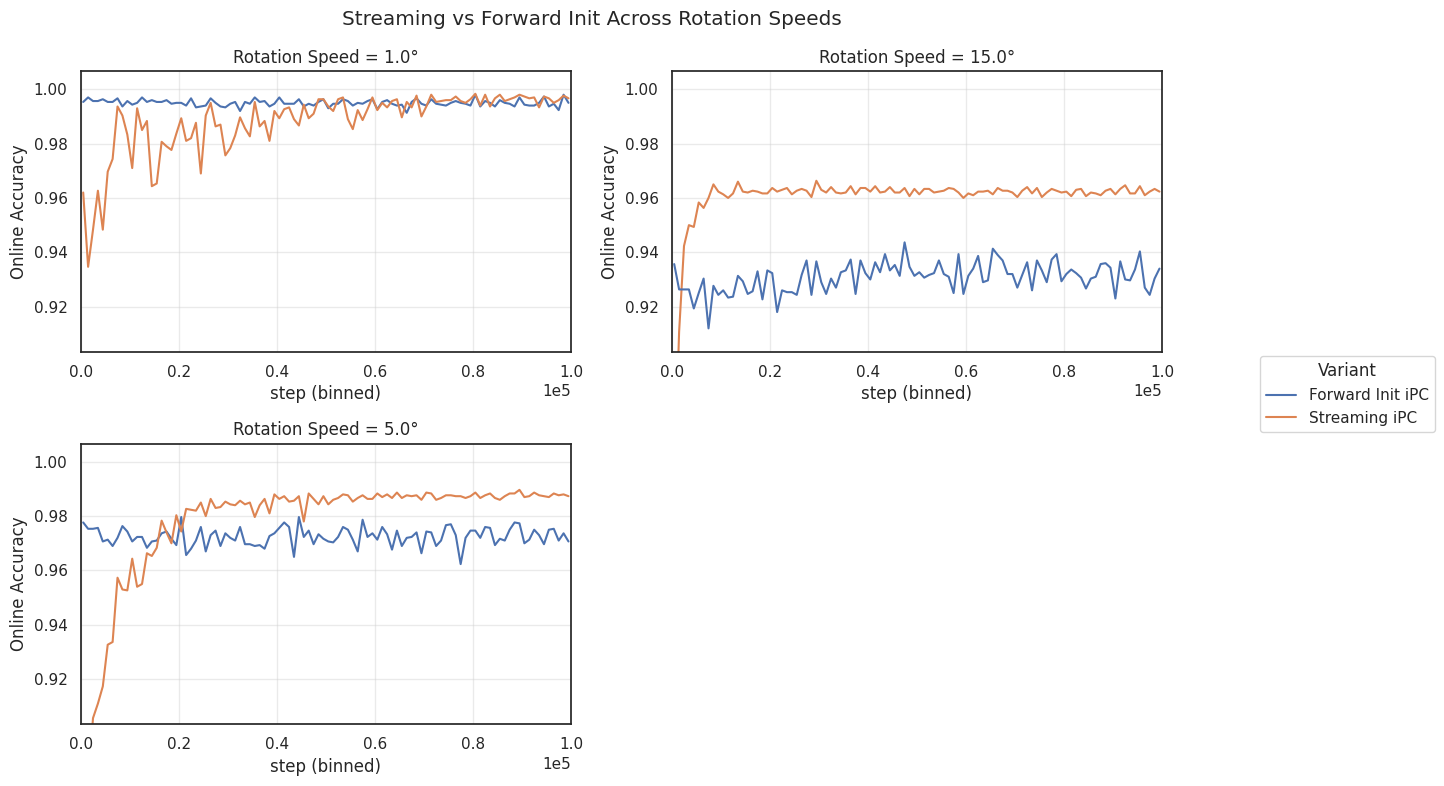

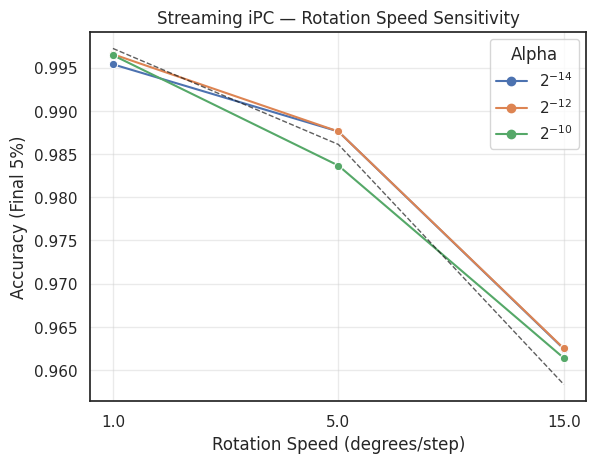

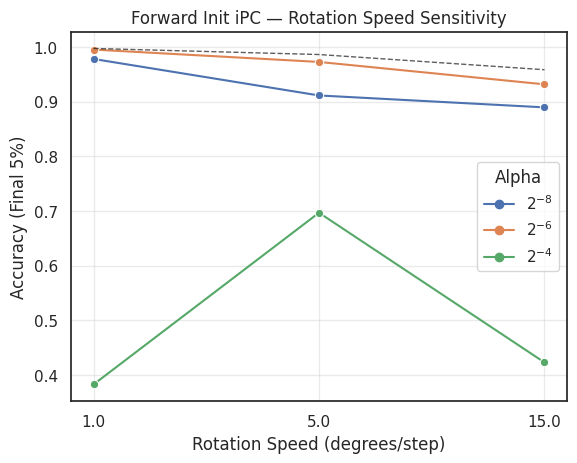

In [20]:
delta_sweeps = ['streaming_delta_sweep', 'forward_init_delta_sweep']
delta_config_dfs = {k: config_dfs[k] for k in delta_sweeps if k in config_dfs}
delta_run_dfs = {k: run_dfs[k] for k in delta_sweeps if k in run_dfs}

if delta_config_dfs:
    # Best alpha per (variant, delta) combination
    best_delta_config, best_delta_runs, best_delta_vals = get_best_ablation_values(
        delta_config_dfs, delta_run_dfs,
        sweep_ablation_vars={k: ['ipc.alpha'] for k in delta_config_dfs},
        sweep_split_vars={k: ['data.delta_degrees'] for k in delta_config_dfs},
        split_dfs_by_split_vars=True,
        metric_col='accuracy',
        metric_direction='max',
        metric_type='final_avg',
    )

    # Combine for comparison
    combined_delta_run = pd.concat(list(best_delta_runs.values()))
    combined_delta_config = pd.concat(
        [df.assign(split=k) for k, df in best_delta_config.items()]
    )

    # Create human-readable labels
    variant_map = {
        'streaming_delta_sweep': 'Streaming iPC',
        'forward_init_delta_sweep': 'Forward Init iPC',
    }
    combined_delta_config['Variant'] = combined_delta_config['split'].apply(
        lambda x: variant_map.get(x.split('&')[0], x.split('&')[0])
    )
    combined_delta_config['delta'] = combined_delta_config['data.delta_degrees'].astype(str) + '°'
    valid_ids = combined_delta_config['run_id'].unique()
    combined_delta_run = combined_delta_run[combined_delta_run['run_id'].isin(valid_ids)]

    plot_learning_curves(
        run_df=combined_delta_run,
        config_df=combined_delta_config,
        n_bins=200,
        figsize=(12, 8),
        y_col='accuracy',
        y_label='Online Accuracy',
        hue_col='Variant',
        subplot_col='delta',
        subplot_col_label='Rotation Speed',
        legend_title='Variant',
        show_ci=True,
    )
    # Add per-subplot baselines
    fig = plt.gcf()
    for ax in fig.axes:
        title = ax.get_title()
        for delta_val in [1, 5, 15]:
            if f'{delta_val}°' in title:
                add_repeat_baseline(delta_degrees=delta_val, ax=ax)
                break
    plt.suptitle('Streaming vs Forward Init Across Rotation Speeds')
    plt.tight_layout()
    plt.show()

    # Delta sensitivity plots per variant
    for sweep_name, label in variant_map.items():
        if sweep_name not in config_dfs:
            continue
        plot_param_sensitivity(
            run_df=run_dfs[sweep_name],
            config_df=config_dfs[sweep_name],
            x_col='data.delta_degrees',
            title=f'{label} — Rotation Speed Sensitivity',
            x_label='Rotation Speed (degrees/step)',
            y_label='Accuracy',
            metric_col='accuracy',
            metric_type='final_avg',
            hue_col='ipc.alpha',
            legend_title='Alpha',
            pow_2_legend=True,
        )
        # Add baseline per delta as dashed line
        deltas = [1, 5, 15]
        x_positions = list(range(len(deltas)))
        baselines = [repeat_baseline_acc(d) for d in deltas]
        plt.plot(x_positions, baselines, 'k--', alpha=0.7, linewidth=1)
        plt.show()

## Figure 6: Architecture Effects

A key concern with streaming iPC is error propagation through depth. In standard PC, multiple inference steps allow errors to propagate across all layers. With T=1, each step only propagates errors one layer — deeper networks may suffer from stale error signals at interior layers.

**Depth sweep** (num_layers in {3, 4, 5}): Tests whether streaming iPC degrades with more layers. A 3-layer network (1 hidden) has minimal propagation issues; a 5-layer network (3 hidden) is more demanding.

**Width sweep** (hidden_dim in {256, 512}): Tests whether wider layers help by providing more representational capacity, or hurt by making the Hebbian weight updates noisier (the outer product update scales with dimension).

**What to look for:**
- If accuracy drops sharply with depth, streaming iPC is limited to shallow architectures.
- If width helps, the bottleneck is capacity rather than error propagation.

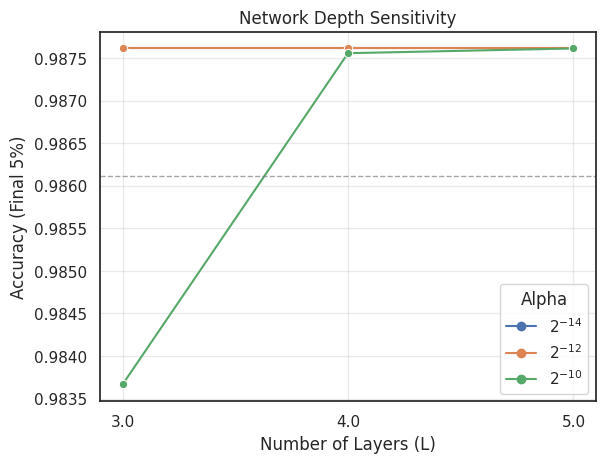

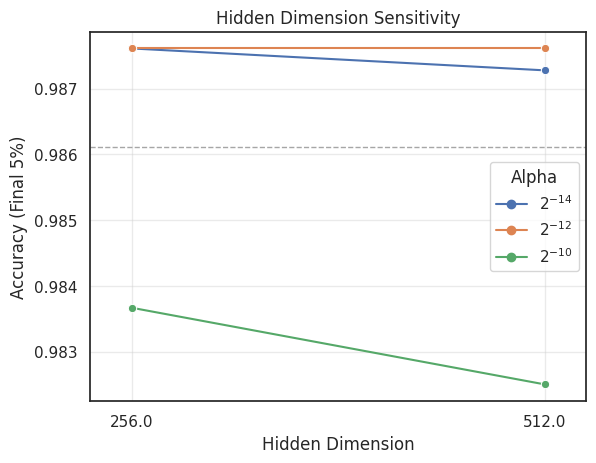

In [21]:
# Depth sensitivity
if 'streaming_depth_sweep' in config_dfs:
    plot_param_sensitivity(
        run_df=run_dfs['streaming_depth_sweep'],
        config_df=config_dfs['streaming_depth_sweep'],
        x_col='model.num_layers',
        title='Network Depth Sensitivity',
        x_label='Number of Layers (L)',
        y_label='Accuracy',
        metric_col='accuracy',
        metric_type='final_avg',
        hue_col='ipc.alpha',
        legend_title='Alpha',
        pow_2_legend=True,
    )
    add_repeat_baseline(delta_degrees=5)
    plt.show()

# Width sensitivity
if 'streaming_width_sweep' in config_dfs:
    plot_param_sensitivity(
        run_df=run_dfs['streaming_width_sweep'],
        config_df=config_dfs['streaming_width_sweep'],
        x_col='model.hidden_dim',
        title='Hidden Dimension Sensitivity',
        x_label='Hidden Dimension',
        y_label='Accuracy',
        metric_col='accuracy',
        metric_type='final_avg',
        hue_col='ipc.alpha',
        legend_title='Alpha',
        pow_2_legend=True,
    )
    add_repeat_baseline(delta_degrees=5)
    plt.show()

## Figure 7: Gamma (Inference LR) Sensitivity

Gamma controls the step size for value node updates: `x[l] += gamma * (-eps[l] + f'(x[l]) * W[l-1].T @ eps[l-1])`. The literature suggests gamma=0.5 is robust across settings. This sweep tests gamma in {0.1, 0.5, 1.0} for streaming iPC.

- **Low gamma (0.1)**: Conservative value node updates. Value nodes change slowly, which could help stability but may not track fast-changing inputs.
- **High gamma (1.0)**: Aggressive updates. Value nodes react quickly to new errors but may overshoot, especially with stale error signals from deeper layers.

**What to look for:**
- Whether gamma=0.5 is indeed robust, or whether the streaming setting prefers a different operating point.
- Interaction with alpha: if high gamma pairs with low alpha (or vice versa), the balance between inference and learning dynamics matters.

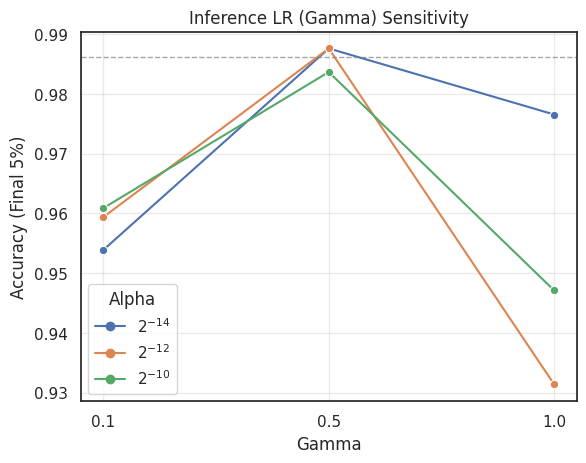

In [22]:
if 'streaming_gamma_sweep' in config_dfs:
    plot_param_sensitivity(
        run_df=run_dfs['streaming_gamma_sweep'],
        config_df=config_dfs['streaming_gamma_sweep'],
        x_col='ipc.gamma',
        title='Inference LR (Gamma) Sensitivity',
        x_label='Gamma',
        y_label='Accuracy',
        metric_col='accuracy',
        metric_type='final_avg',
        hue_col='ipc.alpha',
        legend_title='Alpha',
        pow_2_legend=True,
    )
    add_repeat_baseline(delta_degrees=5)
    plt.show()